# Implied volatility surface (Heston COS - Black–Scholes IV)

Draw Heston parameters with Latin Hypercube Sampling (lhs), price European calls with the COS method and invert Black–Scholes for implied vol on the $(m, \tau)$ grid, use Jäckel’s to solve the IVS. 

In [30]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from implied_volatility_diffusion.iv_surface import implied_vol_surfaces_lhs
from ivd_config import load_config, merge_config

REPO_ROOT = Path("..").resolve()
CFG_PATH = REPO_ROOT / "config" / "heston_iv_surface.yaml"

# Override config
CFG_OVERRIDES: dict = {
    # "lhs": {"n_samples": 32, "n_batches": 1, "seed": 123},
    # "cos": {"n_terms": 2048},
    # "market": {"spot": 100.0},
    # "plot_surface": {"zlim": [0.05, 0.6]},
}

cfg = merge_config(load_config(CFG_PATH), CFG_OVERRIDES or None)
_lhs_ov = (CFG_OVERRIDES or {}).get("lhs")
if not isinstance(_lhs_ov, dict) or "seed" not in _lhs_ov:
    cfg["lhs"]["seed"] = int(np.random.default_rng().integers(0, 2**31, endpoint=False))

cfg["lhs"]["n_samples"], cfg["lhs"]["seed"]

(100, 25915717)

In [31]:
params, m, tau, iv = implied_vol_surfaces_lhs(cfg)
print("params shape:", params.shape, "-> (n_samples, n_params): Heston LHS parameter samples")
print("iv shape:", iv.shape, "-> (n_samples, n_moneyness, n_tau): IVS for all samples")

params shape: (400, 6) -> (n_samples, n_params): Heston LHS parameter samples
iv shape: (400, 9, 6) -> (n_samples, n_moneyness, n_tau): IVS for all samples


## IVS Samples

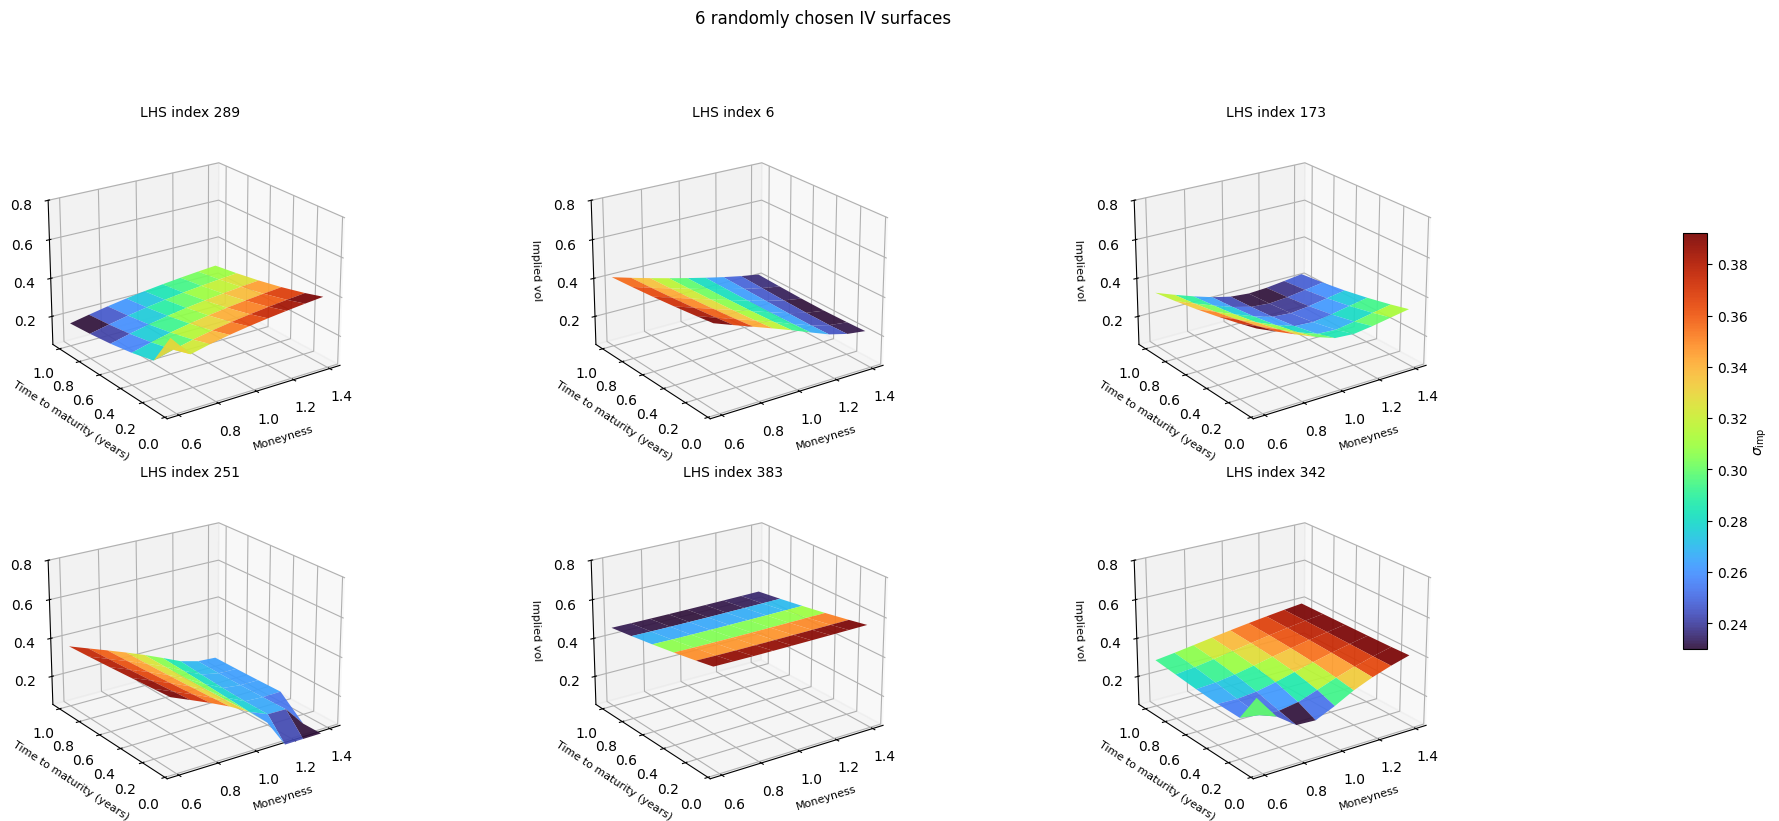

In [47]:
M, TAU = np.meshgrid(m, tau, indexing="ij")

ps = cfg.get("plot_surface", {})
z0, z1 = ps.get("zlim", [0.1, 0.45])
cmap = ps.get("cmap", "turbo")
elev = ps.get("elev", 22)
azim = ps.get("azim", -125)

rng = np.random.default_rng()
n_pick = min(6, iv.shape[0])
idx = rng.choice(iv.shape[0], size=n_pick, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(20, 8), subplot_kw={"projection": "3d"})
surf_last = None
for k, si in enumerate(idx):
    ax = axes.flat[k]
    Z = iv[si]
    surf_last = ax.plot_surface(M, TAU, Z, cmap=cmap, edgecolor="none", alpha=0.92)
    ax.set_zlim(z0, z1)
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel("Moneyness", fontsize=8)
    ax.set_ylabel("Time to maturity (years)", fontsize=8)
    ax.set_zlabel("Implied vol", fontsize=8)
    ax.set_title(f"LHS index {si}", fontsize=10)

fig.suptitle(f"{n_pick} randomly chosen IV surfaces", fontsize=12, y=1.02)
plt.tight_layout(rect=[0, 0, 0.91, 0.96])
if surf_last is not None:
    cax = fig.add_axes([0.93, 0.22, 0.012, 0.52])
    fig.colorbar(surf_last, cax=cax, label=r"$\sigma_{\mathrm{imp}}$")
plt.show()

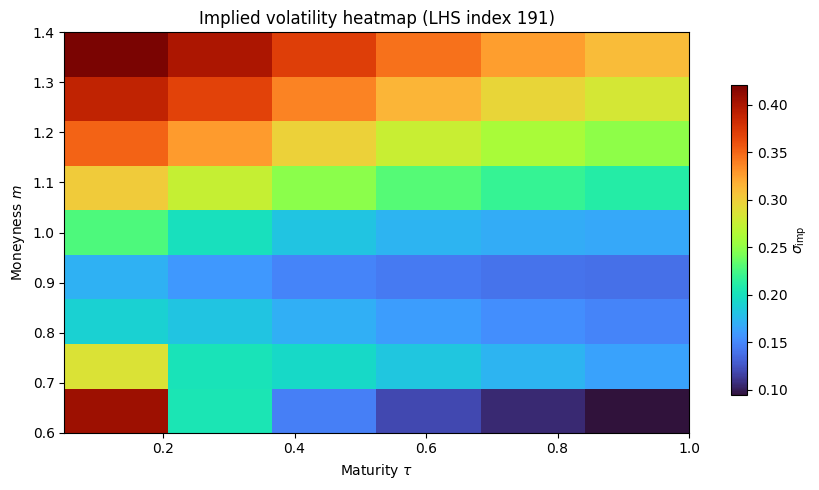

In [44]:
# Heatmap for the first of the random LHS draws
Z_hm = iv[idx[0]]
ps_hm = cfg.get("plot_surface", {})
cmap_hm = ps_hm.get("cmap", "turbo")
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(
    Z_hm,
    origin="lower",
    aspect="auto",
    extent=[tau.min(), tau.max(), m.min(), m.max()],
    cmap=cmap_hm,
)
ax.set_xlabel("Maturity $\\tau$")
ax.set_ylabel("Moneyness $m$")
ax.set_title(f"Implied volatility heatmap (LHS index {idx[0]})")
plt.tight_layout(rect=[0, 0, 0.9, 1])
cax = fig.add_axes([0.92, 0.2, 0.02, 0.62])
fig.colorbar(im, cax=cax, label="$\\sigma_{\\mathrm{imp}}$")
plt.show()

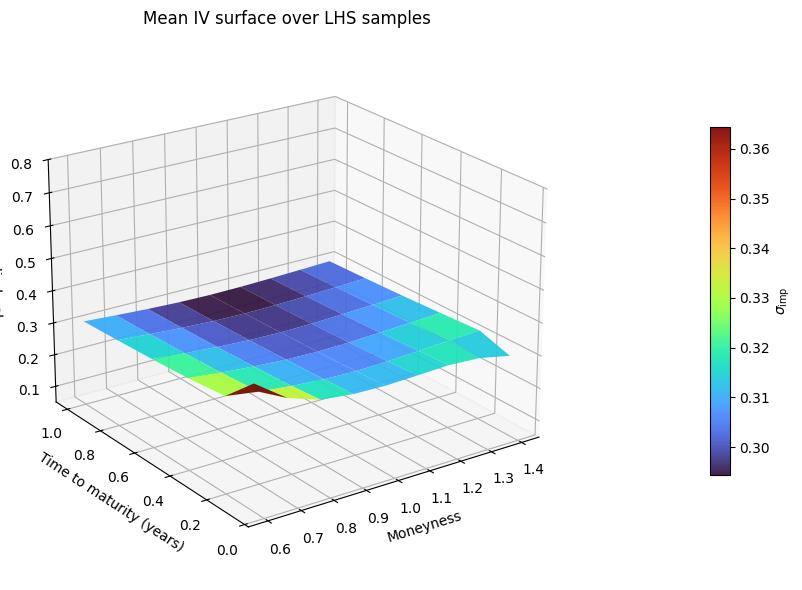

In [34]:
Z_mean = iv.mean(axis=0)
ps = cfg.get("plot_surface", {})
z0, z1 = ps.get("zlim", [0.1, 0.45])
cmap = ps.get("cmap", "turbo")

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(M, TAU, Z_mean, cmap=cmap, edgecolor="none", alpha=0.92)
ax.set_xlabel("Moneyness")
ax.set_ylabel("Time to maturity (years)")
ax.set_zlabel("Implied vol")
ax.set_zlim(z0, z1)
ax.view_init(elev=ps.get("elev", 22), azim=ps.get("azim", -125))
ax.set_title("Mean IV surface over LHS samples")
plt.tight_layout(rect=[0, 0, 0.88, 1])
cax = fig.add_axes([0.91, 0.2, 0.022, 0.58])
fig.colorbar(surf, cax=cax, label="$\\sigma_{\\mathrm{imp}}$")
plt.show()

### Cross-sections: implied vol vs moneyness

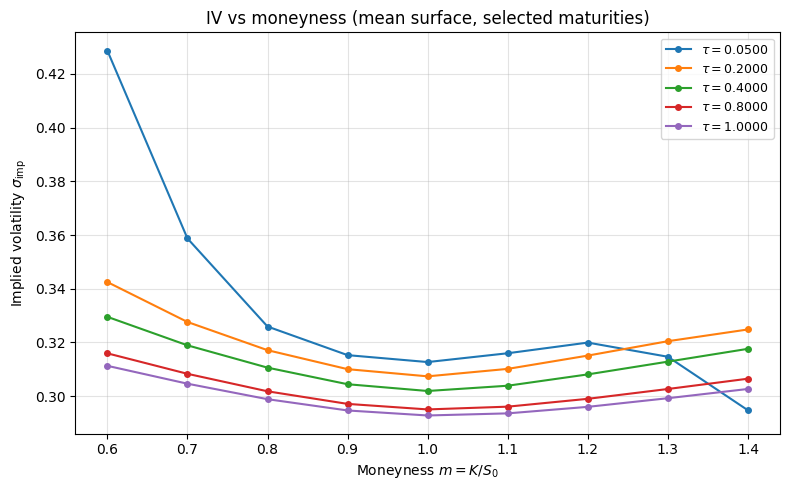

In [35]:
Z_mean = iv.mean(axis=0)

# generate taus
num_sections = 5
j_idx = [round(i * (len(tau) - 1) / (num_sections - 1)) for i in range(num_sections)]

fig, ax = plt.subplots(figsize=(8, 5))
for j in j_idx:
    ax.plot(m, Z_mean[:, j], marker="o", ms=4, lw=1.5, label=rf"$\tau={tau[j]:.4f}$")
ax.set_xlabel(r"Moneyness $m = K/S_0$")
ax.set_ylabel(r"Implied volatility $\sigma_{\mathrm{imp}}$")
ax.set_title("IV vs moneyness (mean surface, selected maturities)")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()